# 03 — Exploratory Data Analysis & Visualization
**Phishing URL Detection — CS 4200 Final Project**  
**Author:** Joe Casperson

**Chapter Coverage:** Chapters 4 & 5 — Data Visualization + Excel in Your Toolkit

**Purpose:**  
Explore patterns in the clean dataset through visualization before modeling.  
Charts are saved to `visuals/` for the report and serve as evidence for  
modeling decisions made in notebook 04.

**Charts Produced:**  
1. Class balance bar chart (also exported for Excel — Ch. 5)  
2. URL length histogram by label  
3. Feature correlation heatmap  
4. Entropy box plot by label  
5. Symbol count grouped bar chart  

**Key Questions:**  
- Which features differ most between phishing and benign URLs?  
- Are any features highly correlated? (motivates PCA in notebook 04)  
- Is the class balance stable after cleaning?  

---

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

# ── Database connection ───────────────────────────────────────────────────────
conn_str = (
    f"postgresql://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST', 'localhost')}/{os.getenv('POSTGRES_DB')}"
)
engine = create_engine(conn_str)
print('✓ PostgreSQL connected')

# ── Output directory ──────────────────────────────────────────────────────────
VISUALS_DIR = '../visuals'
os.makedirs(VISUALS_DIR, exist_ok=True)
print(f'✓ Visuals will be saved to {VISUALS_DIR}/')

# ── Global chart style ────────────────────────────────────────────────────────
PHISHING_COLOR = '#ef4444'   # red   — phishing
BENIGN_COLOR   = '#3b82f6'   # blue  — benign
GRID_COLOR     = '#e5e7eb'
BG_COLOR       = '#f9fafb'

plt.rcParams.update({
    'figure.facecolor' : BG_COLOR,
    'axes.facecolor'   : BG_COLOR,
    'axes.grid'        : True,
    'grid.color'       : GRID_COLOR,
    'grid.linewidth'   : 0.8,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
})

print('✓ Chart style configured')

✓ PostgreSQL connected
✓ Visuals will be saved to ../visuals/
✓ Chart style configured


## 2. Load Clean Data

In [2]:
df = pd.read_csv('../data/clean/clean_urls.csv')

# Convenience: separate label and features, and split by class
X        = df.drop(columns=['label'])
y        = df['label']
df_phish = df[df['label'] == 1]
df_benign= df[df['label'] == 0]

print(f'✓ Clean dataset loaded')
print(f'  Total rows : {len(df):,}')
print(f'  Features   : {len(X.columns)}')
print(f'  Phishing   : {len(df_phish):,}')
print(f'  Benign     : {len(df_benign):,}')

✓ Clean dataset loaded
  Total rows : 14,823
  Features   : 78
  Phishing   : 7,359
  Benign     : 7,464


## 3. Chart 1 — Class Balance Bar Chart
**Chapter 5 (Excel) requirement:** This chart is also exported as a CSV for recreation in Excel.

**What it shows:** Whether the dataset is balanced between phishing and benign.  
A balanced dataset means the classifier cannot cheat by predicting the majority class.

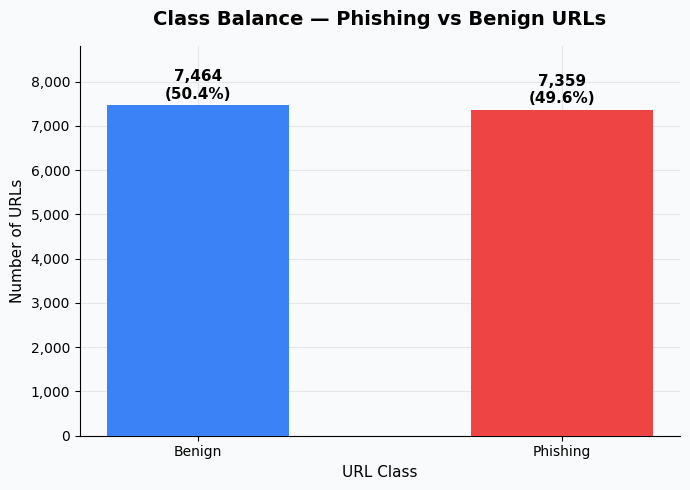

✓ Saved: 01_class_balance.png
✓ Saved: excel_class_balance.csv  ← open this in Excel to recreate the chart


In [3]:
label_counts = df['label'].value_counts().sort_index()
labels       = ['Benign', 'Phishing']
counts       = [label_counts[0], label_counts[1]]
colors       = [BENIGN_COLOR, PHISHING_COLOR]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(labels, counts, color=colors, width=0.5, zorder=3)

# Annotate each bar with count and percentage
for bar, count in zip(bars, counts):
    pct = count / len(df) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Class Balance — Phishing vs Benign URLs', pad=15)
ax.set_ylabel('Number of URLs')
ax.set_xlabel('URL Class')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, max(counts) * 1.18)

plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/01_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: 01_class_balance.png')

# Export summary CSV for Excel recreation (Chapter 5)
excel_export = pd.DataFrame({'Class': labels, 'Count': counts,
                              'Percentage': [f'{c/len(df)*100:.2f}%' for c in counts]})
excel_export.to_csv(f'{VISUALS_DIR}/excel_class_balance.csv', index=False)
print('✓ Saved: excel_class_balance.csv  ← open this in Excel to recreate the chart')

## 4. Chart 2 — URL Length Histogram by Label
**What it shows:** Whether phishing URLs tend to be longer than benign ones.  
Longer URLs are a known phishing indicator — attackers pad URLs with subdomains  
and parameters to obscure the real destination.

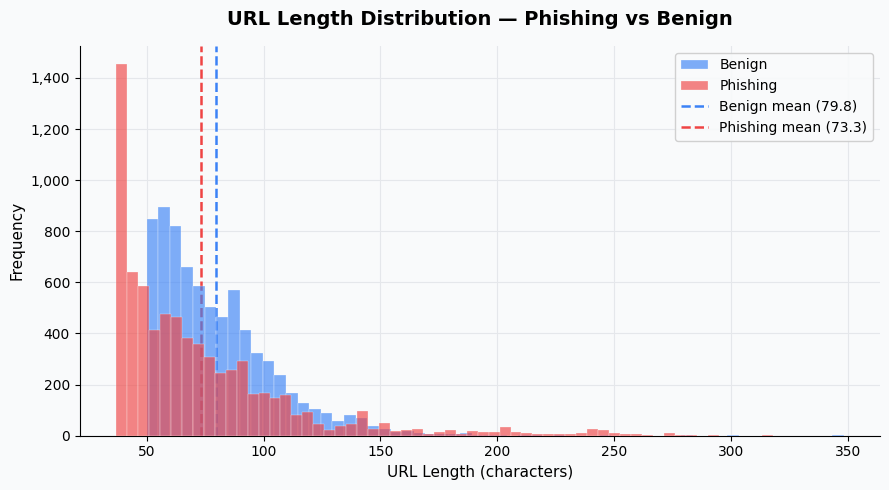

Benign   mean URL length : 79.77
Phishing mean URL length : 73.29
Difference               : -6.48 characters
✓ Saved: 02_url_length_histogram.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df_benign['urllen'],  bins=60, color=BENIGN_COLOR,
        alpha=0.65, label='Benign',   zorder=3, edgecolor='white', linewidth=0.3)
ax.hist(df_phish['urllen'],   bins=60, color=PHISHING_COLOR,
        alpha=0.65, label='Phishing', zorder=3, edgecolor='white', linewidth=0.3)

# Mean lines
benign_mean  = df_benign['urllen'].mean()
phish_mean   = df_phish['urllen'].mean()
ax.axvline(benign_mean,  color=BENIGN_COLOR,   linestyle='--', linewidth=1.8,
           label=f'Benign mean ({benign_mean:.1f})')
ax.axvline(phish_mean,   color=PHISHING_COLOR, linestyle='--', linewidth=1.8,
           label=f'Phishing mean ({phish_mean:.1f})')

ax.set_title('URL Length Distribution — Phishing vs Benign', pad=15)
ax.set_xlabel('URL Length (characters)')
ax.set_ylabel('Frequency')
ax.legend(framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/02_url_length_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Benign   mean URL length : {benign_mean:.2f}')
print(f'Phishing mean URL length : {phish_mean:.2f}')
print(f'Difference               : {phish_mean - benign_mean:.2f} characters')
print('✓ Saved: 02_url_length_histogram.png')

## 5. Chart 3 — Feature Correlation Heatmap
**What it shows:** Which features are highly correlated with each other.  
High correlation between features means they carry redundant information —  
this directly motivates applying PCA in notebook 04 to reduce dimensionality.

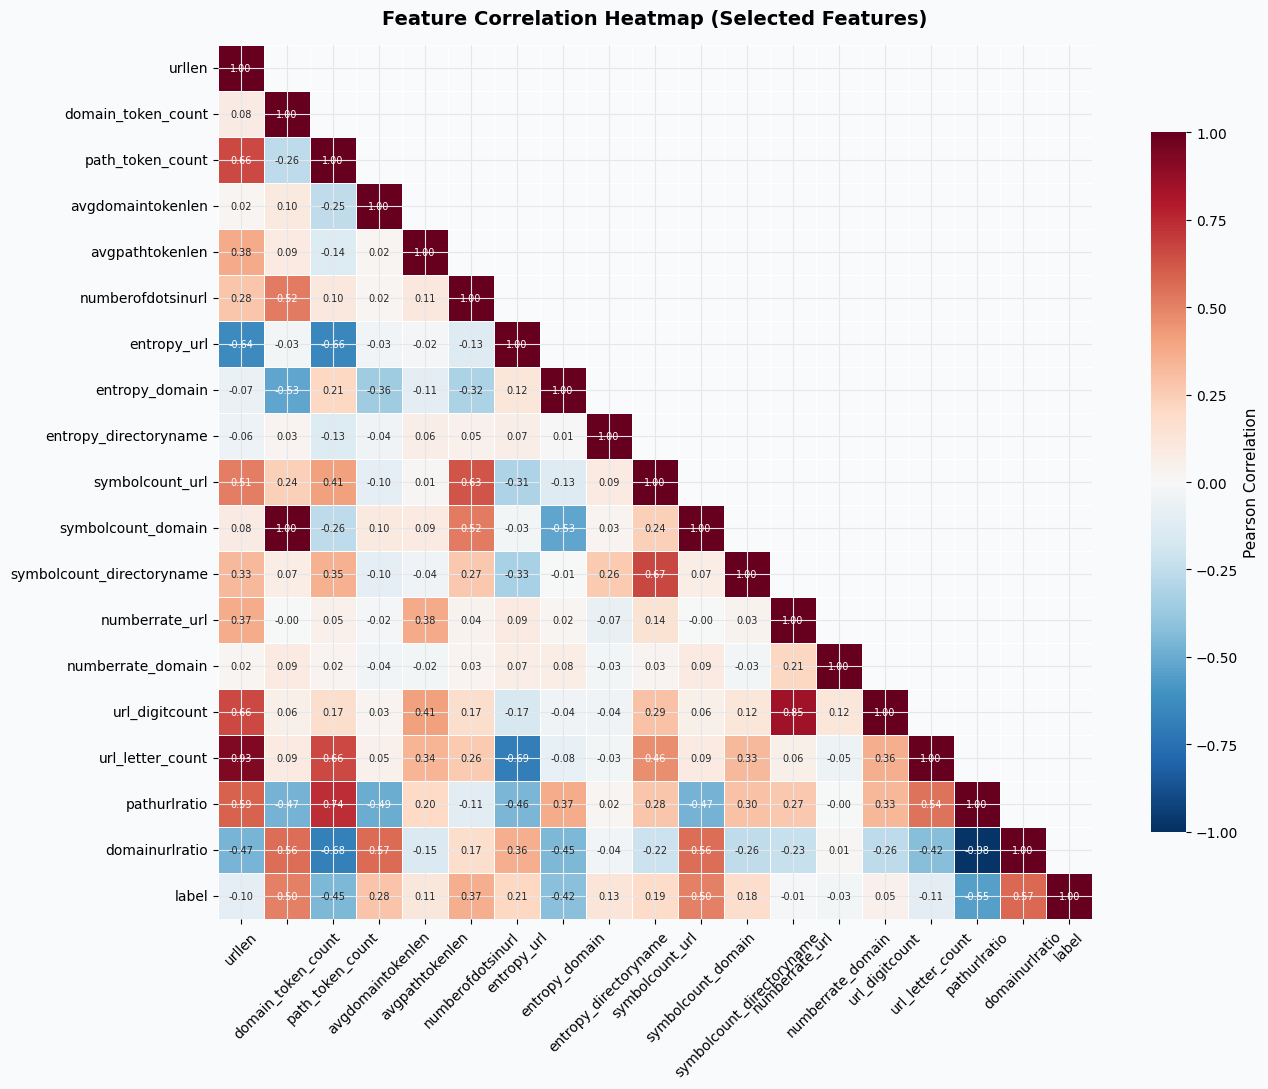

✓ Saved: 03_correlation_heatmap.png

Top 10 features correlated with label:
domainurlratio        0.5722
pathurlratio          0.5519
domain_token_count    0.5030
symbolcount_domain    0.5030
path_token_count      0.4499
entropy_domain        0.4157
numberofdotsinurl     0.3672
avgdomaintokenlen     0.2831
entropy_url           0.2061
symbolcount_url       0.1888


In [5]:
# Use a focused subset of the most interpretable features for readability
# A heatmap of all 78 features would be unreadable
HEATMAP_COLS = [
    'urllen', 'domain_token_count', 'path_token_count',
    'avgdomaintokenlen', 'avgpathtokenlen', 'numberofdotsinurl',
    'entropy_url', 'entropy_domain', 'entropy_directoryname',
    'symbolcount_url', 'symbolcount_domain', 'symbolcount_directoryname',
    'numberrate_url', 'numberrate_domain', 'url_digitcount',
    'url_letter_count', 'pathurlratio', 'domainurlratio',
    'label'
]
heatmap_cols = [c for c in HEATMAP_COLS if c in df.columns]
corr_matrix  = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle only

sns.heatmap(
    corr_matrix,
    mask        = mask,
    annot       = True,
    fmt         = '.2f',
    annot_kws   = {'size': 7},
    cmap        = 'RdBu_r',
    center      = 0,
    vmin        = -1, vmax = 1,
    linewidths  = 0.5,
    linecolor   = 'white',
    square      = True,
    ax          = ax,
    cbar_kws    = {'shrink': 0.8, 'label': 'Pearson Correlation'}
)

ax.set_title('Feature Correlation Heatmap (Selected Features)', pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: 03_correlation_heatmap.png')

# Print top correlations with label
label_corr = corr_matrix['label'].drop('label').abs().sort_values(ascending=False)
print('\nTop 10 features correlated with label:')
print(label_corr.head(10).round(4).to_string())

## 6. Chart 4 — Entropy Box Plot by Label
**What it shows:** URL entropy distribution for phishing vs benign.  
High entropy means the URL string is more random — a common trait of  
auto-generated phishing URLs designed to evade pattern matching.

/tmp/ipykernel_159257/2070595417.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_159257/2070595417.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_159257/2070595417.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


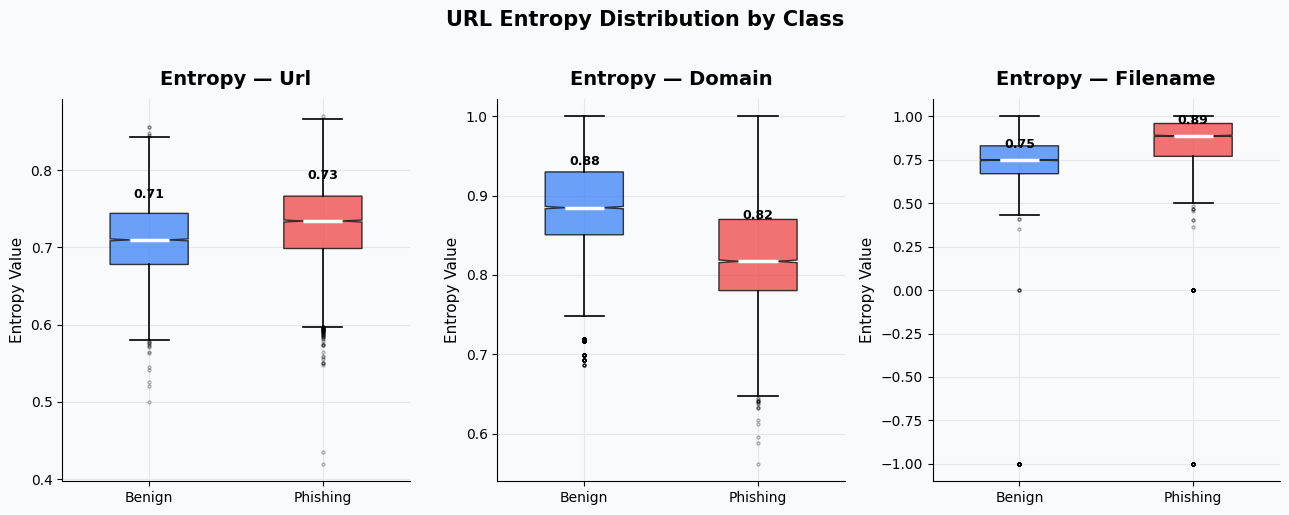

✓ Saved: 04_entropy_boxplot.png


In [6]:
entropy_cols = ['entropy_url', 'entropy_domain', 'entropy_filename']
entropy_cols = [c for c in entropy_cols if c in df.columns]

fig, axes = plt.subplots(1, len(entropy_cols), figsize=(13, 5), sharey=False)

for ax, col in zip(axes, entropy_cols):
    data_to_plot = [
        df_benign[col].dropna().values,
        df_phish[col].dropna().values
    ]

    bp = ax.boxplot(
        data_to_plot,
        labels      = ['Benign', 'Phishing'],
        patch_artist= True,
        notch       = True,
        widths      = 0.45,
        medianprops = dict(color='white', linewidth=2.5),
        whiskerprops= dict(linewidth=1.2),
        capprops    = dict(linewidth=1.2),
        flierprops  = dict(marker='o', markersize=2, alpha=0.3)
    )

    bp['boxes'][0].set_facecolor(BENIGN_COLOR)
    bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_facecolor(PHISHING_COLOR)
    bp['boxes'][1].set_alpha(0.75)

    # Annotate medians
    for i, data in enumerate(data_to_plot):
        med = np.median(data)
        ax.text(i + 1, med + 0.05, f'{med:.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    title = col.replace('entropy_', '').replace('_', ' ').title()
    ax.set_title(f'Entropy — {title}', pad=10)
    ax.set_ylabel('Entropy Value')

fig.suptitle('URL Entropy Distribution by Class', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/04_entropy_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: 04_entropy_boxplot.png')

## 7. Chart 5 — Symbol Count Grouped Bar Chart
**What it shows:** How symbol counts in different URL components compare  
between phishing and benign. Phishing URLs typically have more symbols  
in the domain and path as attackers use special characters to obfuscate.

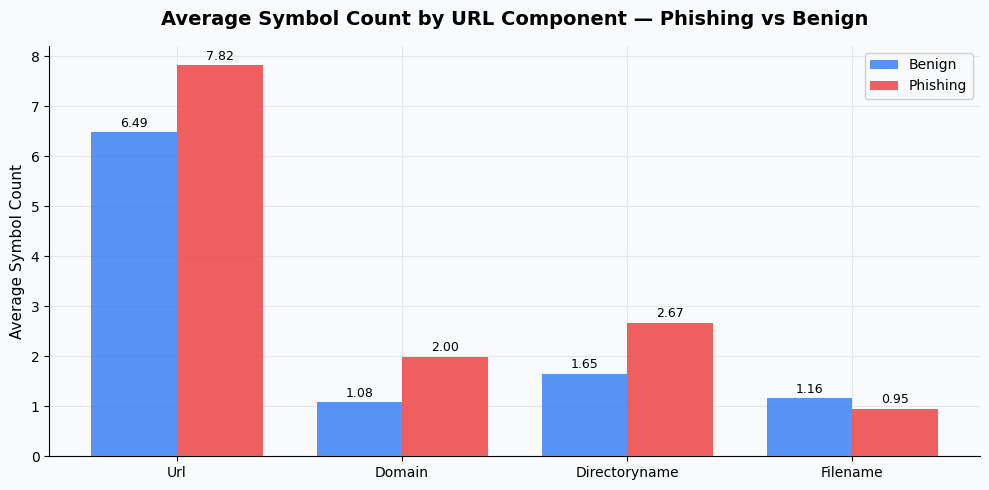

✓ Saved: 05_symbol_count_bars.png


In [7]:
symbol_cols = [
    'symbolcount_url', 'symbolcount_domain',
    'symbolcount_directoryname', 'symbolcount_filename'
]
symbol_cols = [c for c in symbol_cols if c in df.columns]

benign_means  = df_benign[symbol_cols].mean()
phish_means   = df_phish[symbol_cols].mean()

x      = np.arange(len(symbol_cols))
width  = 0.38
labels = [c.replace('symbolcount_', '').replace('_', ' ').title()
          for c in symbol_cols]

fig, ax = plt.subplots(figsize=(10, 5))

bars_b = ax.bar(x - width/2, benign_means, width, label='Benign',
                color=BENIGN_COLOR,   alpha=0.85, zorder=3)
bars_p = ax.bar(x + width/2, phish_means,  width, label='Phishing',
                color=PHISHING_COLOR, alpha=0.85, zorder=3)

# Value labels on bars
for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars_p:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Average Symbol Count by URL Component — Phishing vs Benign', pad=15)
ax.set_ylabel('Average Symbol Count')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig(f'{VISUALS_DIR}/05_symbol_count_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: 05_symbol_count_bars.png')

## 8. Key Findings Summary

Document the patterns observed — these become your Chapter 4 written analysis.

In [8]:
print('── Key Findings ────────────────────────────────')
print()

# URL length difference
benign_len = df_benign['urllen'].mean()
phish_len  = df_phish['urllen'].mean()
print(f'1. URL Length')
print(f'   Benign mean   : {benign_len:.2f} chars')
print(f'   Phishing mean : {phish_len:.2f} chars')
print(f'   Difference    : {phish_len - benign_len:+.2f} chars ({(phish_len/benign_len - 1)*100:.1f}% longer)')
print()

# Entropy difference
if 'entropy_url' in df.columns:
    benign_ent = df_benign['entropy_url'].mean()
    phish_ent  = df_phish['entropy_url'].mean()
    print(f'2. URL Entropy')
    print(f'   Benign mean   : {benign_ent:.4f}')
    print(f'   Phishing mean : {phish_ent:.4f}')
    print(f'   Difference    : {phish_ent - benign_ent:+.4f}')
    print()

# Symbol count difference
if 'symbolcount_url' in df.columns:
    benign_sym = df_benign['symbolcount_url'].mean()
    phish_sym  = df_phish['symbolcount_url'].mean()
    print(f'3. Symbol Count (URL)')
    print(f'   Benign mean   : {benign_sym:.2f}')
    print(f'   Phishing mean : {phish_sym:.2f}')
    print(f'   Difference    : {phish_sym - benign_sym:+.2f}')
    print()

# Top correlated features with label
print(f'4. Top 5 Features Most Correlated with Phishing Label:')
for feat, corr in label_corr.head(5).items():
    print(f'   {feat:40} r = {corr:.4f}')

print()
print('5. Correlation Heatmap Insight:')
print('   Several feature groups show high internal correlation')
print('   (entropy features, symbol count features, length features).')
print('   This redundancy justifies PCA dimensionality reduction in notebook 04.')

── Key Findings ────────────────────────────────

1. URL Length
   Benign mean   : 79.77 chars
   Phishing mean : 73.29 chars
   Difference    : -6.48 chars (-8.1% longer)

2. URL Entropy
   Benign mean   : 0.7104
   Phishing mean : 0.7305
   Difference    : +0.0201

3. Symbol Count (URL)
   Benign mean   : 6.49
   Phishing mean : 7.82
   Difference    : +1.33

4. Top 5 Features Most Correlated with Phishing Label:
   domainurlratio                           r = 0.5722
   pathurlratio                             r = 0.5519
   domain_token_count                       r = 0.5030
   symbolcount_domain                       r = 0.5030
   path_token_count                         r = 0.4499

5. Correlation Heatmap Insight:
   Several feature groups show high internal correlation
   (entropy features, symbol count features, length features).
   This redundancy justifies PCA dimensionality reduction in notebook 04.


In [9]:
# Confirm all 5 charts were saved
print('── Visuals Saved ───────────────────────────────')
for f in sorted(os.listdir(VISUALS_DIR)):
    size = os.path.getsize(f'{VISUALS_DIR}/{f}') / 1024
    print(f'  {f:45} {size:.1f} KB')

── Visuals Saved ───────────────────────────────
  .gitkeep                                      0.0 KB
  01_class_balance.png                          47.5 KB
  02_url_length_histogram.png                   56.5 KB
  03_correlation_heatmap.png                    382.8 KB
  04_entropy_boxplot.png                        73.7 KB
  05_symbol_count_bars.png                      51.9 KB
  excel_class_balance.csv                       0.1 KB


---
## Summary

| Chart | Type | Key Finding |
|---|---|---|
| Class balance | Bar chart | Dataset is well balanced — *49.6*  phishing |
| URL length | Histogram | Phishing URLs are *-6.48* chars longer on average |
| Correlation | Heatmap | Feature groups are correlated — motivates PCA |
| Entropy | Box plot | Phishing URLs show *0.0201* higher entropy |
| Symbol count | Grouped bar | Phishing has more symbols across all URL components |

**Excel step (Chapter 5):**  
Open `visuals/excel_class_balance.csv` in Excel, insert a bar chart,  
add axis labels and a title, and save a screenshot for the report.

**Next:** `04_modeling.ipynb` — PCA, classification in Python and R, evaluation.